# H₂SO₄ Dosing Tank — Multivariable Design Optimization

**Avasa pre-treatment container:** replace NaOH tank `TK-102` with a new H₂SO₄ dosing tank `TK-110` to lower the pH at the ARD mixing junction, suppressing Fe(OH)₃ precipitation (crud) and Fe³⁺ co-extraction while keeping Cu extraction by LIX 984N high.

**Decision variables** (stated priority order, with range and objective direction):

| # | Parameter | Range | Direction |
|---|---|---|---|
| 1 | pH at mixing junction | 1.5 – 2.0 | minimize |
| 2 | Tank size | 100 – 1200 L | minimize |
| 3 | Initial tank purchase cost | — | minimize |
| 4 | Cu extracted (%) | 50 – 100 | maximize |
| 5 | Fe³⁺ co-extracted (%) | 0 – 10 | minimize |
| 6 | Refill interval | 5 – 8.5 d | minimize |
| 7 | H₂SO₄ concentration | 20 – 30 w/w% | minimize |

Chemistry follows the memo's method: second dissociation of H₂SO₄ solved explicitly with Ka₂ = 1.02×10⁻², first dissociation treated as complete.

**Method:** dense grid search over (pH, w/w%, refill interval) × discrete tank material → feasibility screen (100–1200 L, Fe ≤ 10%, Cu ≥ 50%) → min–max normalization → Rank Order Centroid (ROC) weighted score reflecting the stated priority order → optimum + Pareto front.

**Literature anchors for Fe³⁺ co-extraction by LIX 984N** (composite curve — replace with in-house data when available):
- ≤6.4% at pH 1.9 (10% LIX 984N, dilute leach liquor) — SAIMM 2014
- 20–28% at pH 4.5 (6% LIX 984N, hexane) — Sridhar 2011
- Best reported Cu/Fe separation near pH 1.5 — Qing-ming 2008

## 1. Setup and fixed process parameters

In [1]:
import numpy as np
from scipy.interpolate import PchipInterpolator
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LogNorm

%matplotlib inline
mpl.rcParams.update({"font.size": 10, "figure.dpi": 120,
                     "axes.grid": True, "grid.alpha": 0.3})

In [2]:
# Fixed process parameters (from memo)
Q_ARD   = 44.0          # L/min, ARD feed to mixing junction
PH_ARD  = 3.5           # assumed ARD pH (memo assumption)
KA2     = 1.02e-2       # HSO4- <-> H+ + SO4^2-
MW      = 0.09808       # kg/mol H2SO4
FREEBOARD = 1.15        # 15% ullage / safety on tank sizing

# Density of aqueous H2SO4 vs w/w% at ~20 C (Perry's, interpolated)
RHO_W  = np.array([20, 22, 24, 25, 26, 28, 30])          # w/w %
RHO_KG = np.array([1.1394, 1.1548, 1.1704, 1.1783,
                   1.1862, 1.2023, 1.2185])              # kg/L
rho_h2so4 = PchipInterpolator(RHO_W, RHO_KG)

## 2. Extraction curves vs equilibrium pH

Cu curve digitized from **Figure 2** of the memo (Sridhar & Verma 2011, LIX 984N, room temperature). Fe³⁺ co-extraction is a composite built from the literature anchors above — swap in in-house isotherm data here when available.

In [3]:
# Cu — digitized from Figure 2 (Sridhar & Verma 2011, LIX 984N, RT)
CU_PH  = np.array([0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 3.7, 3.9])
CU_PCT = np.array([15., 31., 70., 85., 96.8, 97.5, 99.3, 99.3, 99.3])
cu_extraction = PchipInterpolator(CU_PH, CU_PCT)

# Fe3+ co-extraction — composite literature curve (see intro). Swap in
# in-house isotherm data here when available.
FE_PH  = np.array([1.0, 1.5, 1.9, 2.5, 3.5, 4.5])
FE_PCT = np.array([2.0, 3.5, 6.4, 10.5, 17.0, 24.0])
fe_coextraction = PchipInterpolator(FE_PH, FE_PCT)

## 3. Dosing chemistry (memo's Ka₂ method)

In [4]:
def s_required(ph_target):
    """Total sulfur (mol/L as H2SO4) in mixed stream to hit target pH.
    x = [H+] contributed by the acid; S = x(x+Ka2)/(x+2Ka2)."""
    x = 10.0 ** (-np.asarray(ph_target, dtype=float))
    return x * (x + KA2) / (x + 2.0 * KA2)

def acid_molarity(w_pct):
    """mol/L of H2SO4 stock at w/w% concentration."""
    return rho_h2so4(w_pct) * (w_pct / 100.0) / MW

def q_acid(ph_target, w_pct):
    """Dosing flow (L/min): C*Q_acid = S_req*(Q_ARD + Q_acid)."""
    S = s_required(ph_target)
    C = acid_molarity(w_pct)
    return S * Q_ARD / (C - S)

def tank_volume(ph_target, w_pct, t_days):
    """Working volume + freeboard for one refill interval (L)."""
    return q_acid(ph_target, w_pct) * 1440.0 * t_days * FREEBOARD

## 4. Tank cost model — indicative budgetary pricing

`Cost = base_1000L × f_material × (V / 1000 L)^0.62` (six-tenths-rule scaling).

Material suitability for 20–30 w/w% H₂SO₄ at ambient temperature:

| Material | Suitability |
|---|---|
| HDPE / XLPE | Excellent — industry standard for dilute sulfuric |
| FRP (vinyl ester) | Excellent with corrosion barrier |
| PP-lined FRP | Excellent |
| SS316L | **Not recommended** — 20–30% H₂SO₄ at 25 °C sits in the high-corrosion trough of the iso-corrosion chart (>0.5–1 mm/y); shown for comparison only |
| Alloy 20 | Suitable but costly (built for mid-range H₂SO₄) |

In [5]:
MATERIALS = {
    #  name                 f_mat  suitable
    "HDPE/XLPE":           (1.00,  True),
    "FRP (vinyl ester)":   (1.65,  True),
    "PP-lined FRP":        (1.95,  True),
    "SS316L":              (3.10,  False),
    "Alloy 20":            (6.50,  True),
}
BASE_COST_1000L = 650.0   # USD, molded HDPE chemical tank ~1000 L

def tank_cost(volume_l, material):
    f, _ = MATERIALS[material]
    return BASE_COST_1000L * f * (np.maximum(volume_l, 1.0) / 1000.0) ** 0.62

## 5. Grid search and feasibility screen

In [6]:
ph_grid = np.linspace(1.5, 2.0, 101)
w_grid  = np.linspace(20.0, 30.0, 41)
t_grid  = np.linspace(5.0, 8.5, 15)

PH, W, T = np.meshgrid(ph_grid, w_grid, t_grid, indexing="ij")
V    = tank_volume(PH, W, T)
QA   = q_acid(PH, W)
CU   = cu_extraction(PH)
FE   = fe_coextraction(PH)

feasible = (V >= 100.0) & (V <= 1200.0) & (FE <= 10.0) & (CU >= 50.0)
print(f"Grid points: {feasible.size:,}   feasible: {feasible.sum():,} "
      f"({100*feasible.mean():.1f}%)")

# Minimum achievable pH under the 1200 L cap (at w=30%, t=5 d)
v_at_best = tank_volume(ph_grid, 30.0, 5.0)
ph_floor = ph_grid[np.argmax(v_at_best <= 1200.0)]
print(f"pH floor imposed by 1200 L tank cap (w=30%, t=5 d): {ph_floor:.2f}")

Grid points: 62,115   feasible: 6,911 (11.1%)
pH floor imposed by 1200 L tank cap (w=30%, t=5 d): 1.77


## 6. Weighted scoring (Rank Order Centroid over the 7 priorities)

ROC weights convert the *stated priority order* into numeric weights without requiring the user to specify exact trade-off ratios — weight for rank *i* of *n* is the average of `1/i ... 1/n`.

In [7]:
n_crit = 7
roc = np.array([np.sum(1.0 / np.arange(i, n_crit + 1)) / n_crit
                for i in range(1, n_crit + 1)])
CRITERIA = ["pH (min)", "Tank vol (min)", "Cost (min)", "Cu % (max)",
            "Fe % (min)", "Refill days (min)", "Acid w/w% (min)"]
print("ROC weights:")
for c, wgt in zip(CRITERIA, roc):
    print(f"  {c:<18s} {wgt:.3f}")

ROC weights:
  pH (min)           0.370
  Tank vol (min)     0.228
  Cost (min)         0.156
  Cu % (max)         0.109
  Fe % (min)         0.073
  Refill days (min)  0.044
  Acid w/w% (min)    0.020


In [8]:
def norm(arr, minimize=True):
    a = arr[feasible]
    lo, hi = a.min(), a.max()
    z = (arr - lo) / (hi - lo) if hi > lo else np.zeros_like(arr)
    return z if minimize else 1.0 - z

best = {}
for mat in MATERIALS:
    COST = tank_cost(V, mat)
    score = (roc[0] * norm(PH) + roc[1] * norm(V) + roc[2] * norm(COST)
             + roc[3] * norm(CU, minimize=False) + roc[4] * norm(FE)
             + roc[5] * norm(T) + roc[6] * norm(W))
    score_f = np.where(feasible, score, np.inf)
    idx = np.unravel_index(np.argmin(score_f), score_f.shape)
    best[mat] = dict(ph=PH[idx], w=W[idx], t=T[idx], V=V[idx],
                     Q=QA[idx], cu=CU[idx], fe=FE[idx],
                     cost=COST[idx], score=score[idx], idx=idx)

print("=== Optimal design per material (ROC-weighted) ===")
hdr = (f"{'Material':<18s}{'pH':>6s}{'w/w%':>7s}{'t(d)':>6s}{'V(L)':>8s}"
       f"{'Q(L/min)':>10s}{'Cu%':>7s}{'Fe%':>6s}{'Cost$':>8s}{'Score':>8s}")
print(hdr); print("-" * len(hdr))
for mat, b in best.items():
    suit = "" if MATERIALS[mat][1] else "  << NOT suitable @20-30% H2SO4"
    print(f"{mat:<18s}{b['ph']:>6.2f}{b['w']:>7.1f}{b['t']:>6.1f}"
          f"{b['V']:>8.0f}{b['Q']:>10.3f}{b['cu']:>7.1f}{b['fe']:>6.1f}"
          f"{b['cost']:>8.0f}{b['score']:>8.3f}{suit}")

# Recommended = cheapest suitable material's optimum
rec_mat = min((m for m in MATERIALS if MATERIALS[m][1]),
              key=lambda m: best[m]["cost"])
R = best[rec_mat]
print(f"\n>>> RECOMMENDED: {rec_mat} | pH {R['ph']:.2f} | {R['w']:.0f} w/w% "
      f"| refill {R['t']:.1f} d | tank {R['V']:.0f} L | Q_acid "
      f"{R['Q']:.3f} L/min ({R['Q']*1440:.0f} L/d) | Cu {R['cu']:.1f}% "
      f"| Fe {R['fe']:.1f}% | ~${R['cost']:.0f}")

=== Optimal design per material (ROC-weighted) ===
Material              pH   w/w%  t(d)    V(L)  Q(L/min)    Cu%   Fe%   Cost$   Score
------------------------------------------------------------------------------------
HDPE/XLPE           1.94   30.0   5.0     765     0.092   83.5   6.7     550   0.459
FRP (vinyl ester)   1.94   30.0   5.0     765     0.092   83.5   6.7     908   0.459
PP-lined FRP        1.94   30.0   5.0     765     0.092   83.5   6.7    1073   0.459
SS316L              1.94   30.0   5.0     765     0.092   83.5   6.7    1706   0.459  << NOT suitable @20-30% H2SO4
Alloy 20            1.94   30.0   5.0     765     0.092   83.5   6.7    3578   0.459

>>> RECOMMENDED: HDPE/XLPE | pH 1.94 | 30 w/w% | refill 5.0 d | tank 765 L | Q_acid 0.092 L/min (133 L/d) | Cu 83.5% | Fe 6.7% | ~$550


## 7. Pareto front (Cu% vs tank volume) at 30 w/w%, 5-day refill

In [9]:
def pareto_mask(cu_arr, v_arr):
    """Non-dominated: maximize cu, minimize v."""
    order = np.argsort(v_arr)
    mask = np.zeros_like(cu_arr, dtype=bool)
    best_cu = -np.inf
    for i in order:
        if cu_arr[i] > best_cu:
            mask[i] = True
            best_cu = cu_arr[i]
    return mask

sl_v  = tank_volume(ph_grid, 30.0, 5.0)
sl_cu = cu_extraction(ph_grid)
sl_fe = fe_coextraction(ph_grid)
sl_ok = (sl_v >= 100) & (sl_v <= 1200)
pmask = pareto_mask(sl_cu[sl_ok], sl_v[sl_ok])

## 8. Visualizations

### Fig 1 — the core trade-off: Cu vs Fe³⁺ extraction vs pH

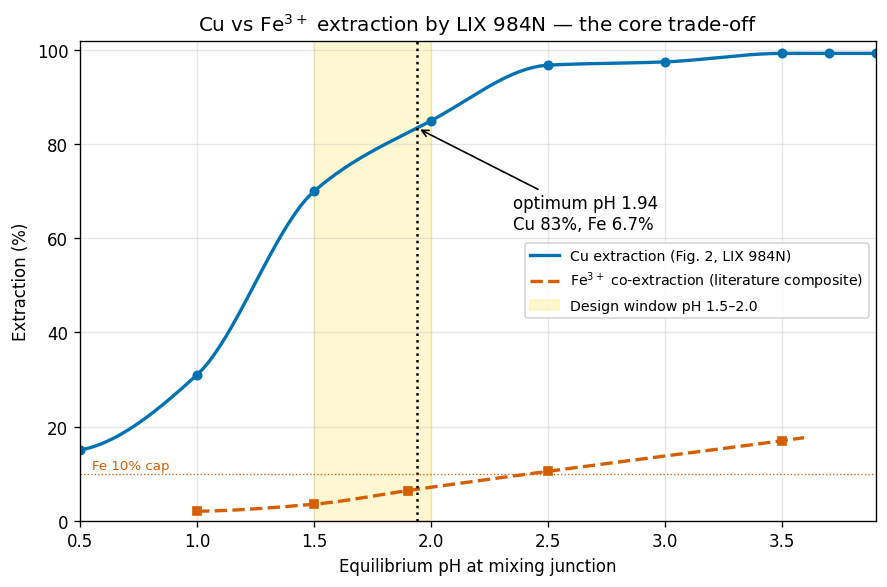

In [10]:
C_ACC, C_ALT, C_BAD = "#0072B2", "#D55E00", "#CC3311"

figA, ax = plt.subplots(figsize=(7.5, 5))
phx = np.linspace(0.5, 3.9, 300)
ax.plot(phx, cu_extraction(phx), color=C_ACC, lw=2, label="Cu extraction (Fig. 2, LIX 984N)")
ax.plot(CU_PH, CU_PCT, "o", color=C_ACC, ms=5)
fe_rng = (phx >= 1.0) & (phx <= 3.6)   # no extrapolation below first anchor
ax.plot(phx[fe_rng], fe_coextraction(phx[fe_rng]), color=C_ALT, lw=2,
        ls="--", label="Fe$^{3+}$ co-extraction (literature composite)")
ax.plot(FE_PH[:-1], FE_PCT[:-1], "s", color=C_ALT, ms=5)
ax.axvspan(1.5, 2.0, color="gold", alpha=0.18, label="Design window pH 1.5–2.0")
ax.axvline(R["ph"], color="k", ls=":", lw=1.5)
ax.annotate(f"optimum pH {R['ph']:.2f}\nCu {R['cu']:.0f}%, Fe {R['fe']:.1f}%",
            xy=(R["ph"], R["cu"]), xytext=(2.35, 62),
            arrowprops=dict(arrowstyle="->", lw=1))
ax.axhline(10, color=C_ALT, lw=0.8, ls=":")
ax.text(0.55, 11, "Fe 10% cap", color=C_ALT, fontsize=8)
ax.set(xlabel="Equilibrium pH at mixing junction", ylabel="Extraction (%)",
       title="Cu vs Fe$^{3+}$ extraction by LIX 984N — the core trade-off",
       xlim=(0.5, 3.9), ylim=(0, 102))
ax.legend(loc="center right", fontsize=8.5)
plt.tight_layout()
plt.show()

### Fig 2 — acid demand and tank sizing vs pH

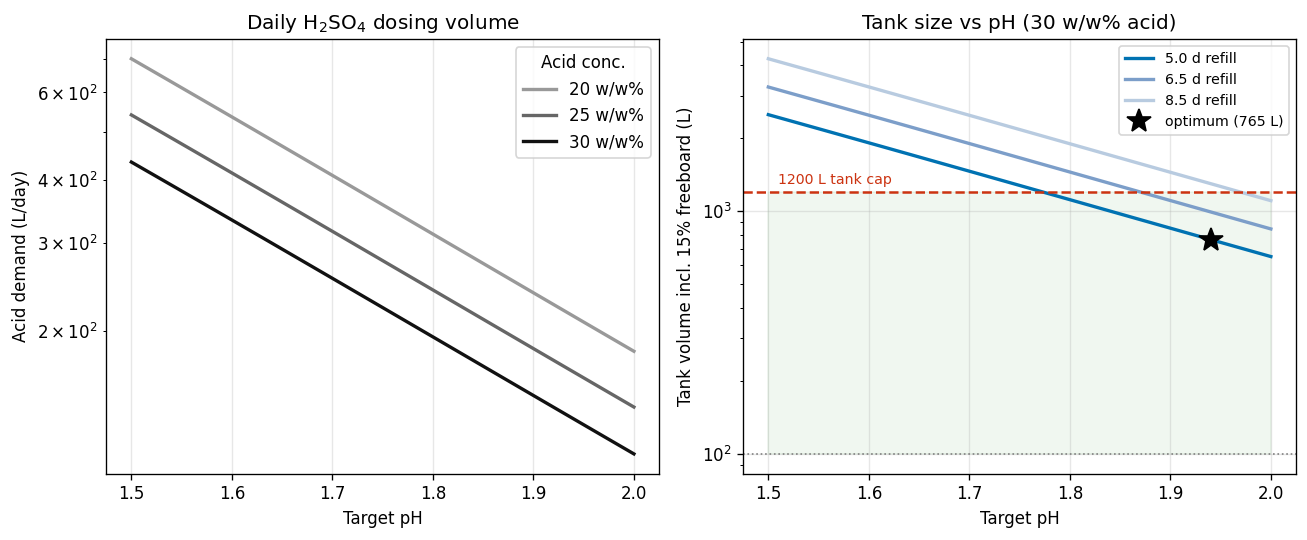

In [11]:
figB, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.6))
for wv, cstyle in zip([20, 25, 30], ["#999999", "#666666", "#111111"]):
    ax1.plot(ph_grid, q_acid(ph_grid, wv) * 1440, color=cstyle, lw=2,
             label=f"{wv} w/w%")
ax1.set(xlabel="Target pH", ylabel="Acid demand (L/day)",
        title="Daily H$_2$SO$_4$ dosing volume")
ax1.legend(title="Acid conc."); ax1.set_yscale("log")

for tv, cstyle in zip([5.0, 6.5, 8.5], [C_ACC, "#7c9ec9", "#b8cbe0"]):
    ax2.plot(ph_grid, tank_volume(ph_grid, 30.0, tv), color=cstyle, lw=2,
             label=f"{tv:.1f} d refill")
ax2.axhline(1200, color=C_BAD, lw=1.5, ls="--")
ax2.text(1.51, 1290, "1200 L tank cap", color=C_BAD, fontsize=8.5)
ax2.axhline(100, color="gray", lw=1, ls=":")
ax2.fill_between(ph_grid, 100, 1200, color="green", alpha=0.06)
ax2.plot(R["ph"], R["V"], "k*", ms=15, zorder=5,
         label=f"optimum ({R['V']:.0f} L)")
ax2.set(xlabel="Target pH", ylabel="Tank volume incl. 15% freeboard (L)",
        title="Tank size vs pH (30 w/w% acid)", yscale="log")
ax2.legend(fontsize=8.5)
plt.tight_layout()
plt.show()

### Fig 3 — feasible design space (pH × acid concentration)

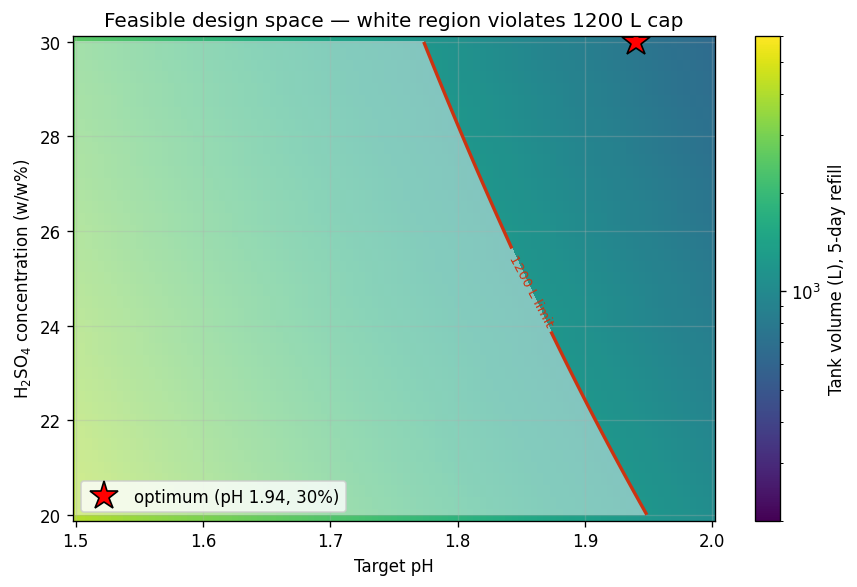

In [12]:
figC, ax = plt.subplots(figsize=(7.5, 5))
PH2, W2 = np.meshgrid(ph_grid, w_grid, indexing="ij")
V2 = tank_volume(PH2, W2, 5.0)
pc = ax.pcolormesh(PH2, W2, V2, norm=LogNorm(vmin=200, vmax=6000),
                   cmap="viridis", shading="auto")
cs = ax.contour(PH2, W2, V2, levels=[1200], colors=[C_BAD], linewidths=2)
ax.clabel(cs, fmt="1200 L limit", fontsize=8)
ax.contourf(PH2, W2, V2, levels=[1200, 1e9], colors="white", alpha=0.45)
ax.plot(R["ph"], R["w"], "*", color="red", ms=18, mec="k",
        label=f"optimum (pH {R['ph']:.2f}, {R['w']:.0f}%)")
figC.colorbar(pc, label="Tank volume (L), 5-day refill")
ax.set(xlabel="Target pH", ylabel="H$_2$SO$_4$ concentration (w/w%)",
       title="Feasible design space — white region violates 1200 L cap")
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

### Fig 4 — Pareto trade-off and tank cost by material

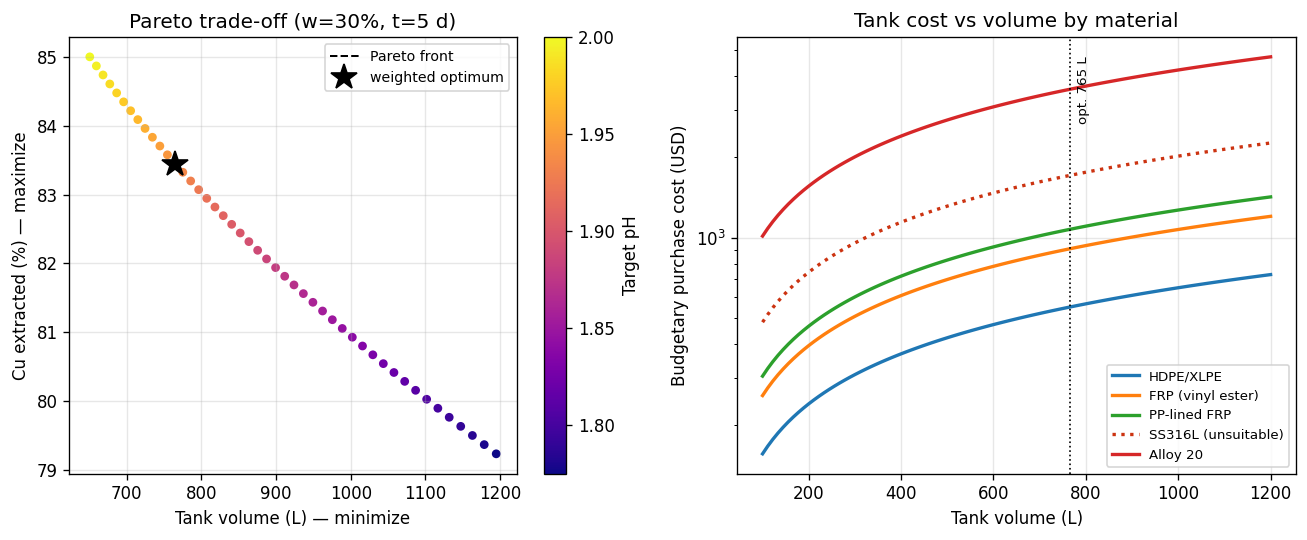

In [13]:
figD, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.6))
sc = ax1.scatter(sl_v[sl_ok], sl_cu[sl_ok], c=ph_grid[sl_ok],
                 cmap="plasma", s=18)
vp, cp = sl_v[sl_ok][pmask], sl_cu[sl_ok][pmask]
o = np.argsort(vp)
ax1.plot(vp[o], cp[o], color="k", lw=1.2, ls="--", label="Pareto front")
ax1.plot(R["V"], R["cu"], "k*", ms=16, zorder=5, label="weighted optimum")
figD.colorbar(sc, ax=ax1, label="Target pH")
ax1.set(xlabel="Tank volume (L) — minimize", ylabel="Cu extracted (%) — maximize",
        title="Pareto trade-off (w=30%, t=5 d)")
ax1.legend(fontsize=8.5)

vols = np.linspace(100, 1200, 100)
for mat, (f, ok) in MATERIALS.items():
    style = dict(lw=2) if ok else dict(lw=2, ls=":", color=C_BAD)
    ax2.plot(vols, tank_cost(vols, mat), label=mat + ("" if ok else " (unsuitable)"),
             **style)
ax2.axvline(R["V"], color="k", ls=":", lw=1)
ax2.text(R["V"] + 15, ax2.get_ylim()[1] * 0.55, f"opt. {R['V']:.0f} L",
         rotation=90, fontsize=8)
ax2.set(xlabel="Tank volume (L)", ylabel="Budgetary purchase cost (USD)",
        title="Tank cost vs volume by material", yscale="log")
ax2.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Fig 5 — sensitivity around the optimum

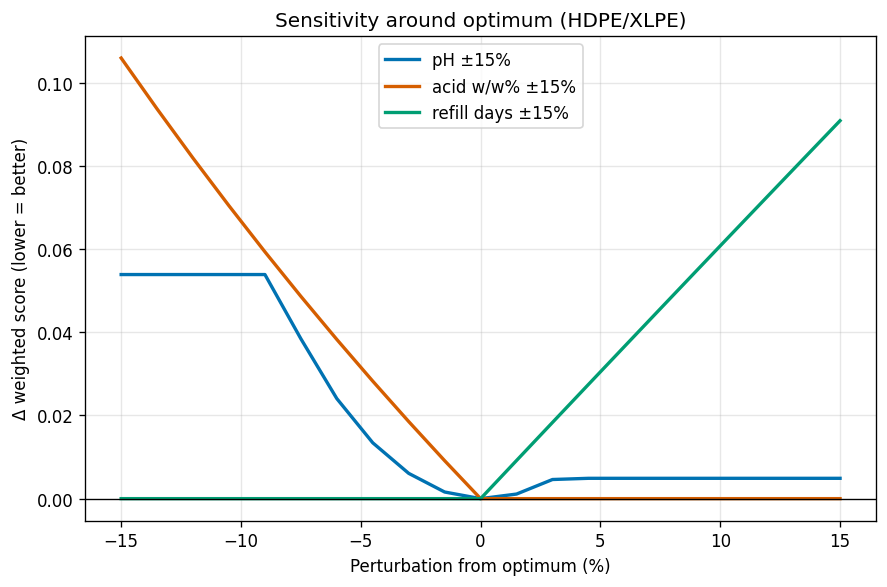

In [14]:
figE, ax = plt.subplots(figsize=(7.5, 5))
base_score = R["score"]
pert = np.linspace(-0.15, 0.15, 21)
COSTR = tank_cost(V, rec_mat)

def scored(ph, w, t):
    v = tank_volume(ph, w, t)
    c = tank_cost(v, rec_mat)
    def n1(x, arr, mn=True):
        a = arr[feasible]; lo, hi = a.min(), a.max()
        z = (x - lo) / (hi - lo)
        return np.clip(z, 0, 1) if mn else 1 - np.clip(z, 0, 1)
    return (roc[0]*n1(ph, PH) + roc[1]*n1(v, V) + roc[2]*n1(c, COSTR)
            + roc[3]*n1(cu_extraction(ph), CU, mn=False)
            + roc[4]*n1(fe_coextraction(ph), FE)
            + roc[5]*n1(t, T) + roc[6]*n1(w, W))

for label, fn, cstyle in [
    ("pH ±15%",     lambda p: scored(np.clip(R["ph"]*(1+p), 1.5, 2.0), R["w"], R["t"]), C_ACC),
    ("acid w/w% ±15%", lambda p: scored(R["ph"], np.clip(R["w"]*(1+p), 20, 30), R["t"]), C_ALT),
    ("refill days ±15%", lambda p: scored(R["ph"], R["w"], np.clip(R["t"]*(1+p), 5, 8.5)), "#009E73"),
]:
    ax.plot(pert*100, [fn(p) - base_score for p in pert], lw=2,
            color=cstyle, label=label)
ax.axhline(0, color="k", lw=0.8)
ax.set(xlabel="Perturbation from optimum (%)",
       ylabel="Δ weighted score (lower = better)",
       title=f"Sensitivity around optimum ({rec_mat})")
ax.legend()
plt.tight_layout()
plt.show()

## 9. Summary and caveats

**Key finding:** the 1200 L tank cap makes pH 1.5 unreachable. Even at 30 w/w% acid and a 5-day refill, holding pH 1.5 needs ~2,500 L. The real feasible window is **pH ≈ 1.77–2.0**, not 1.5–2.0.

**Recommended design:** pH 1.94, 30 w/w% H₂SO₄, 5-day refill, 765 L tank (HDPE/XLPE, ~$550 budgetary), Cu ≈ 83.5%, Fe³⁺ ≈ 6.7%.

**Caveats:**
- The Fe³⁺ co-extraction curve is a literature composite stitched from three studies with different LIX loadings and Fe tenors — replace `FE_PH`/`FE_PCT` with in-house isotherm data as soon as it's available.
- The Ka₂ dosing model inherits the memo's assumption of an unbuffered ARD feed at pH 3.5. Real ARD carrying dissolved Fe/Al will buffer the mixing junction and increase acid demand — treat the acid-volume numbers as a lower bound until validated against a titration of actual feed.
- Tank costs are indicative six-tenths-rule correlations, not vendor quotes — update `BASE_COST_1000L` and the `MATERIALS` multipliers once Rachanashakti/Karadani-class pricing is in hand.
- If 25 w/w% acid is preferred for commonality with the stripping circuit, set `w_grid = np.array([25.0])` and re-run — the optimum shifts to roughly 918 L at the same pH.